In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import cross_validate
from tqdm import tqdm

## 1. Data loading

Dane wejściowe miały postać zagnieżdżonego pliku JSON, w którym każdy mecz zawierał informacje ogólne oraz listę graczy ze statystykami.
W funkcji `flatten_matches()` dane zostały przekształcone do postaci tabelarycznej, gdzie **jeden wiersz odpowiada jednemu graczowi w jednym meczu**.

Do każdego rekordu dołączono:
- informacje o meczu, np. czas trwania, wynik, patch i tryb gry,
- statystyki pojedynczego gracza, np. zabójstwa, asysty, net worth, GPM, XPM czy obrażenia.

Dodatkowo obliczono cechy względne względem drużyny, takie jak udział gracza w zabójstwach, majątku i zadanych obrażeniach. Jest to przydatne, ponieważ same wartości bezwzględne nie zawsze dobrze opisują wpływ gracza na przebieg meczu — ten sam wynik może mieć inne znaczenie w zależności od siły całej drużyny.

## 2. Feature engineering

W kolejnym kroku zbudowano cechy na poziomie całego meczu za pomocą funkcji `build_match_features()`.
Statystyki graczy zostały zagregowane tak, aby **jeden wiersz odpowiadał jednemu meczowi**, co jest wygodne w dalszym modelowaniu.

Uwzględniono kilka grup cech:
- **cechy meta meczu** — np. czas trwania, first blood, liczba zabójstw, patch,
- **cechy ekonomiczne** — np. GPM, XPM, net worth, last hits,
- **cechy bojowe** — np. kills, assists, KDA, hero damage,
- **cechy obiektów** — np. tower damage,
- **cechy drużynowe** — średnie, sumy i różnice między zwycięzcą a przegranym.

Taki dobór cech pozwala opisać mecz z kilku perspektyw.
Cechy ekonomiczne pokazują efektywność zdobywania zasobów, cechy bojowe opisują aktywność w walkach, a cechy obiektów i drużynowe pomagają uchwycić kontrolę mapy oraz organizację gry zespołowej. Dzięki temu model dostaje pełniejszy obraz jakości rozgrywki, co może pomóc w rozróżnianiu rang.

Dodatkowo przygotowano kilka wariantów zestawów cech w funkcji `get_feature_groups()`.
Pozwala to porównywać, które grupy informacji są najbardziej użyteczne w predykcji. Przykładowo:
- wariant **economy** skupia się głównie na cechach ekonomicznych,
- wariant **combat** koncentruje się na statystykach walk,
- wariant **macro** podkreśla aspekt makrogry i realizacji celów,
- wariant **compact** stanowi krótszy, bardziej zbalansowany zestaw cech,
- wariant **full** wykorzystuje pełny zestaw dostępnych informacji.

In [2]:
MATCH_META_COLS = [
    "match_id",
    "tier",
    "radiant_win",
    "duration",
    "pre_game_duration",
    "start_time",
    "tower_status_radiant",
    "tower_status_dire",
    "barracks_status_radiant",
    "barracks_status_dire",
    "first_blood_time",
    "human_players",
    "leagueid",
    "game_mode",
    "lobby_type",
    "radiant_score",
    "dire_score",
    "patch",
    "cluster",
]

PLAYER_COLS = [
    "player_slot",
    "team_number",
    "team_slot",
    "hero_id",
    "hero_variant",
    "kills",
    "deaths",
    "assists",
    "last_hits",
    "denies",
    "gold_per_min",
    "xp_per_min",
    "level",
    "net_worth",
    "hero_damage",
    "tower_damage",
    "hero_healing",
    "gold",
    "gold_spent",
    "total_gold",
    "total_xp",
    "kills_per_min",
    "kda",
    "aghanims_scepter",
    "aghanims_shard",
    "moonshard",
    "isRadiant",
    "win",
    "lose",
]

ECON_METRICS = [
    "gold_per_min",
    "xp_per_min",
    "net_worth",
    "last_hits",
    "denies",
    "level",
    "gold_spent",
    "total_gold",
    "total_xp",
]

COMBAT_METRICS = [
    "kills",
    "deaths",
    "assists",
    "kda",
    "hero_damage",
    "hero_healing",
    "kills_per_min",
    "kill_participation_proxy",
]

OBJECTIVE_METRICS = [
    "tower_damage",
]

SHARE_METRICS = [
    "net_worth_share",
    "gpm_share",
    "hero_damage_share",
]

ITEM_COUNT_METRICS = [
    "aghanims_scepter",
    "aghanims_shard",
    "moonshard",
]


def safe_bit_count(x):
    if pd.isna(x):
        return np.nan
    try:
        return int(int(x).bit_count())
    except Exception:
        return np.nan


def add_stats_from_series(out_dict, series, prefix, stats=("mean", "std")):
    s = pd.to_numeric(series, errors="coerce")

    if "sum" in stats:
        out_dict[f"{prefix}_sum"] = s.sum(skipna=True)
    if "mean" in stats:
        out_dict[f"{prefix}_mean"] = s.mean(skipna=True)
    if "std" in stats:
        out_dict[f"{prefix}_std"] = s.std(skipna=True, ddof=0)
    if "min" in stats:
        out_dict[f"{prefix}_min"] = s.min(skipna=True)
    if "max" in stats:
        out_dict[f"{prefix}_max"] = s.max(skipna=True)
    if "range" in stats:
        out_dict[f"{prefix}_range"] = s.max(skipna=True) - s.min(skipna=True)


def add_team_distribution_features(out_dict, team_df, prefix, cols):

    for col in cols:
        if col in team_df.columns:
            add_stats_from_series(
                out_dict,
                team_df[col],
                f"{prefix}_{col}",
                stats=("mean", "std", "min", "max", "range"),
            )


def add_team_share_features(out_dict, team_df, prefix):

    for col in SHARE_METRICS:
        if col in team_df.columns:
            add_stats_from_series(
                out_dict,
                team_df[col],
                f"{prefix}_{col}",
                stats=("mean", "std", "max"),
            )


def add_team_item_counts(out_dict, team_df, prefix):
    for col in ITEM_COUNT_METRICS:
        if col in team_df.columns:
            out_dict[f"{prefix}_{col}_count"] = (
                pd.to_numeric(team_df[col], errors="coerce").fillna(0).sum()
            )


def add_ranked_player_features(out_dict, team_df, prefix, sort_col="net_worth"):

    if sort_col not in team_df.columns:
        return

    tmp = team_df.copy()
    tmp[sort_col] = pd.to_numeric(tmp[sort_col], errors="coerce")
    tmp = tmp.sort_values(sort_col, ascending=False).reset_index(drop=True)

    cols_to_export = [
        "net_worth",
        "gold_per_min",
        "xp_per_min",
        "last_hits",
        "hero_damage",
        "kills",
        "deaths",
        "assists",
        "kda",
    ]

    n = min(5, len(tmp))
    for i in range(n):
        for col in cols_to_export:
            if col in tmp.columns:
                out_dict[f"{prefix}_rank{i + 1}_{col}"] = tmp.loc[i, col]


def get_feature_groups(feature_set="full"):

    feature_set = feature_set.lower()

    if feature_set == "economy":
        return {
            "match_meta": True,
            "economy": True,
            "combat": False,
            "objectives": False,
            "shares": True,
            "team_balance": True,
            "team_ranked": True,
            "team_diff": True,
            "items": False,
        }

    if feature_set == "combat":
        return {
            "match_meta": True,
            "economy": False,
            "combat": True,
            "objectives": False,
            "shares": True,
            "team_balance": True,
            "team_ranked": False,
            "team_diff": True,
            "items": False,
        }

    if feature_set == "macro":
        return {
            "match_meta": True,
            "economy": True,
            "combat": False,
            "objectives": True,
            "shares": False,
            "team_balance": False,
            "team_ranked": False,
            "team_diff": True,
            "items": True,
        }

    if feature_set == "compact":
        return {
            "match_meta": True,
            "economy": True,
            "combat": True,
            "objectives": True,
            "shares": True,
            "team_balance": True,
            "team_ranked": False,
            "team_diff": True,
            "items": True,
        }

    return {
        "match_meta": True,
        "economy": True,
        "combat": True,
        "objectives": True,
        "shares": True,
        "team_balance": True,
        "team_ranked": True,
        "team_diff": True,
        "items": True,
    }


def flatten_matches(json_data):
    rows = []

    for fallback_idx, match in enumerate(json_data):
        match_id = match.get("match_id", fallback_idx)

        match_meta = {}
        for col in MATCH_META_COLS:
            match_meta[col] = match_id if col == "match_id" else match.get(col, np.nan)

        for p in match.get("players", []):
            row = match_meta.copy()
            for col in PLAYER_COLS:
                row[col] = p.get(col, np.nan)
            rows.append(row)

    df = pd.DataFrame(rows)

    team_kills = (
        df.groupby(["match_id", "isRadiant"])["kills"]
        .transform("sum")
        .replace(0, np.nan)
    )
    team_net_worth = (
        df.groupby(["match_id", "isRadiant"])["net_worth"]
        .transform("sum")
        .replace(0, np.nan)
    )
    team_gpm = (
        df.groupby(["match_id", "isRadiant"])["gold_per_min"]
        .transform("sum")
        .replace(0, np.nan)
    )
    team_hero_damage = (
        df.groupby(["match_id", "isRadiant"])["hero_damage"]
        .transform("sum")
        .replace(0, np.nan)
    )

    df["kill_participation_proxy"] = (df["kills"] + df["assists"]) / team_kills
    df["net_worth_share"] = df["net_worth"] / team_net_worth
    df["gpm_share"] = df["gold_per_min"] / team_gpm
    df["hero_damage_share"] = df["hero_damage"] / team_hero_damage

    return df


def build_match_features(
    players_df,
    feature_set="full",
    drop_constant=True,
    include_winner_loser=True,
):

    cfg = get_feature_groups(feature_set)
    rows = []

    meta_cols = [
        "match_id",
        "tier",
        "radiant_win",
        "duration",
        "pre_game_duration",
        "tower_status_radiant",
        "tower_status_dire",
        "barracks_status_radiant",
        "barracks_status_dire",
        "first_blood_time",
        "human_players",
        "leagueid",
        "game_mode",
        "lobby_type",
        "radiant_score",
        "dire_score",
        "patch",
        "cluster",
    ]

    all_base_metrics = []
    if cfg["economy"]:
        all_base_metrics += ECON_METRICS
    if cfg["combat"]:
        all_base_metrics += COMBAT_METRICS
    if cfg["objectives"]:
        all_base_metrics += OBJECTIVE_METRICS

    all_base_metrics = list(dict.fromkeys(all_base_metrics))

    for match_id, df_match in players_df.groupby("match_id", sort=False):
        df_match = df_match.copy()

        meta = {
            col: df_match.iloc[0][col] if col in df_match.columns else np.nan
            for col in meta_cols
        }

        radiant_df = df_match[df_match["isRadiant"] == 1].copy()
        dire_df = df_match[df_match["isRadiant"] == 0].copy()

        radiant_win = meta["radiant_win"]

        if pd.notna(radiant_win) and int(radiant_win) == 1:
            winner_df, loser_df = radiant_df, dire_df
            winner_prefix = "winner"
            loser_prefix = "loser"
        else:
            winner_df, loser_df = dire_df, radiant_df
            winner_prefix = "winner"
            loser_prefix = "loser"

        duration_min = (
            meta["duration"] / 60
            if pd.notna(meta["duration"]) and meta["duration"] > 0
            else np.nan
        )
        first_blood_min = (
            meta["first_blood_time"] / 60
            if pd.notna(meta["first_blood_time"])
            else np.nan
        )

        radiant_score = meta["radiant_score"] if pd.notna(meta["radiant_score"]) else 0
        dire_score = meta["dire_score"] if pd.notna(meta["dire_score"]) else 0
        total_kills_match = radiant_score + dire_score

        row = {}

        if cfg["match_meta"]:
            row.update(
                {
                    "match_id": meta["match_id"],
                    "tier": meta["tier"],
                    "radiant_win": meta["radiant_win"],
                    "duration_min": duration_min,
                    "pre_game_duration": meta["pre_game_duration"],
                    "first_blood_min": first_blood_min,
                    "radiant_score": radiant_score,
                    "dire_score": dire_score,
                    "total_kills_match": total_kills_match,
                    "kill_diff_abs": abs(radiant_score - dire_score),
                    "game_mode": meta["game_mode"],
                    "lobby_type": meta["lobby_type"],
                    "patch": meta["patch"],
                    "cluster": meta["cluster"],
                    "leagueid": meta["leagueid"],
                    "human_players": meta["human_players"],
                    "kills_per_min_match": (
                        total_kills_match / duration_min
                        if pd.notna(duration_min) and duration_min > 0
                        else np.nan
                    ),
                }
            )

            radiant_towers_alive = safe_bit_count(meta["tower_status_radiant"])
            dire_towers_alive = safe_bit_count(meta["tower_status_dire"])
            radiant_barracks_alive = safe_bit_count(meta["barracks_status_radiant"])
            dire_barracks_alive = safe_bit_count(meta["barracks_status_dire"])

            row["tower_alive_diff_abs"] = (
                abs(radiant_towers_alive - dire_towers_alive)
                if pd.notna(radiant_towers_alive) and pd.notna(dire_towers_alive)
                else np.nan
            )
            row["barracks_alive_diff_abs"] = (
                abs(radiant_barracks_alive - dire_barracks_alive)
                if pd.notna(radiant_barracks_alive) and pd.notna(dire_barracks_alive)
                else np.nan
            )

            if pd.notna(radiant_win) and int(radiant_win) == 1:
                row["winner_towers_alive"] = radiant_towers_alive
                row["loser_towers_alive"] = dire_towers_alive
                row["winner_barracks_alive"] = radiant_barracks_alive
                row["loser_barracks_alive"] = dire_barracks_alive
            else:
                row["winner_towers_alive"] = dire_towers_alive
                row["loser_towers_alive"] = radiant_towers_alive
                row["winner_barracks_alive"] = dire_barracks_alive
                row["loser_barracks_alive"] = radiant_barracks_alive

        for col in all_base_metrics:
            if col in df_match.columns:
                add_stats_from_series(
                    row,
                    df_match[col],
                    f"all_{col}",
                    stats=("mean", "std"),
                )

        if include_winner_loser:
            for col in all_base_metrics:
                if col not in winner_df.columns:
                    continue

                if col in [
                    "net_worth",
                    "last_hits",
                    "denies",
                    "kills",
                    "deaths",
                    "assists",
                    "hero_damage",
                    "tower_damage",
                    "hero_healing",
                    "gold_spent",
                    "total_gold",
                    "total_xp",
                ]:
                    add_stats_from_series(
                        row, winner_df[col], f"{winner_prefix}_{col}", stats=("sum",)
                    )
                    add_stats_from_series(
                        row, loser_df[col], f"{loser_prefix}_{col}", stats=("sum",)
                    )

                if col in [
                    "gold_per_min",
                    "xp_per_min",
                    "level",
                    "kda",
                    "kill_participation_proxy",
                    "kills_per_min",
                ]:
                    add_stats_from_series(
                        row, winner_df[col], f"{winner_prefix}_{col}", stats=("mean",)
                    )
                    add_stats_from_series(
                        row, loser_df[col], f"{loser_prefix}_{col}", stats=("mean",)
                    )

        if cfg["team_balance"]:
            balance_cols = []
            if cfg["economy"]:
                balance_cols += [
                    "gold_per_min",
                    "xp_per_min",
                    "net_worth",
                    "last_hits",
                    "denies",
                    "level",
                ]
            if cfg["combat"]:
                balance_cols += ["kills", "deaths", "assists", "kda", "hero_damage"]
            if cfg["objectives"]:
                balance_cols += ["tower_damage"]

            balance_cols = list(dict.fromkeys(balance_cols))

            add_team_distribution_features(
                row, winner_df, "winner_balance", balance_cols
            )
            add_team_distribution_features(row, loser_df, "loser_balance", balance_cols)

        if cfg["shares"]:
            add_team_share_features(row, winner_df, "winner_share")
            add_team_share_features(row, loser_df, "loser_share")

        if cfg["items"]:
            add_team_item_counts(row, winner_df, "winner")
            add_team_item_counts(row, loser_df, "loser")

        if cfg["team_ranked"]:
            add_ranked_player_features(row, winner_df, "winner")
            add_ranked_player_features(row, loser_df, "loser")

        if cfg["team_diff"]:
            diff_sum_cols = [
                "net_worth",
                "last_hits",
                "denies",
                "kills",
                "deaths",
                "assists",
                "hero_damage",
                "tower_damage",
                "hero_healing",
                "gold_spent",
                "total_gold",
                "total_xp",
            ]
            diff_mean_cols = [
                "gold_per_min",
                "xp_per_min",
                "level",
                "kda",
                "kill_participation_proxy",
                "kills_per_min",
            ]

            for col in diff_sum_cols:
                w = row.get(f"winner_{col}_sum", np.nan)
                l = row.get(f"loser_{col}_sum", np.nan)
                row[f"diff_{col}_sum"] = (
                    w - l if pd.notna(w) and pd.notna(l) else np.nan
                )

            for col in diff_mean_cols:
                w = row.get(f"winner_{col}_mean", np.nan)
                l = row.get(f"loser_{col}_mean", np.nan)
                row[f"diff_{col}_mean"] = (
                    w - l if pd.notna(w) and pd.notna(l) else np.nan
                )

            if cfg["shares"]:
                for col in SHARE_METRICS:
                    w = row.get(f"winner_share_{col}_max", np.nan)
                    l = row.get(f"loser_share_{col}_max", np.nan)
                    row[f"diff_{col}_max"] = (
                        w - l if pd.notna(w) and pd.notna(l) else np.nan
                    )

            if pd.notna(duration_min) and duration_min > 0:
                per_min_cols = ["net_worth", "last_hits", "tower_damage", "hero_damage"]
                for col in per_min_cols:
                    w = row.get(f"winner_{col}_sum", np.nan)
                    l = row.get(f"loser_{col}_sum", np.nan)

                    row[f"winner_{col}_per_min"] = (
                        w / duration_min if pd.notna(w) else np.nan
                    )
                    row[f"loser_{col}_per_min"] = (
                        l / duration_min if pd.notna(l) else np.nan
                    )
                    row[f"diff_{col}_per_min"] = (
                        (w - l) / duration_min
                        if pd.notna(w) and pd.notna(l)
                        else np.nan
                    )

        rows.append(row)

    match_df = pd.DataFrame(rows)

    if drop_constant:
        nunique = match_df.nunique(dropna=False)
        constant_cols = [
            c for c in nunique[nunique <= 1].index if c not in ["match_id", "tier"]
        ]
        if constant_cols:
            match_df = match_df.drop(columns=constant_cols)

    return match_df


def drop_high_corr_features(df, threshold=0.95, exclude_cols=("match_id", "tier")):
    work_df = df.drop(
        columns=[c for c in exclude_cols if c in df.columns], errors="ignore"
    )

    corr = work_df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    reduced_df = df.drop(columns=to_drop, errors="ignore")
    return reduced_df, to_drop

In [3]:
with open("data/competition_train.json", "r") as f:
    train_json = json.load(f)

with open("data/competition_test.json", "r") as f:
    test_json = json.load(f)

exploration_df = build_match_features(flatten_matches(train_json), feature_set="full")
exploration_df.head()

,match_id,tier,radiant_win,duration_min,pre_game_duration,first_blood_min,radiant_score,dire_score,total_kills_match,kill_diff_abs,...,diff_net_worth_per_min,winner_last_hits_per_min,loser_last_hits_per_min,diff_last_hits_per_min,winner_tower_damage_per_min,loser_tower_damage_per_min,diff_tower_damage_per_min,winner_hero_damage_per_min,loser_hero_damage_per_min,diff_hero_damage_per_min
0,8734611758,Ancient,True,24.133333,60,1.800000,34,17,51,17,...,1185.455801,21.712707,13.756906,7.955801,733.342541,199.930939,533.411602,4285.897790,2876.767956,1409.129834
1,8734606174,Crusader,True,21.900000,60,0.650000,34,27,61,7,...,1753.105023,20.593607,16.986301,3.607306,1049.863014,467.990868,581.872146,4757.305936,3621.872146,1135.433790
2,8734590288,Divine,False,64.150000,90,2.883333,36,56,92,20,...,547.170694,28.246298,35.962588,-7.716290,519.438815,115.027280,404.411535,4345.705378,4006.313328,339.392050
3,8322747411,Legend,True,31.400000,90,1.750000,54,23,77,31,...,1215.605096,24.171975,17.675159,6.496815,1032.547771,16.878981,1015.668790,3704.458599,2937.292994,767.165605
4,8734587750,Immortal,True,27.800000,90,0.800000,40,23,63,17,...,840.719424,23.129496,21.690647,1.438849,1198.345324,16.618705,1181.726619,3159.928058,2481.402878,678.525180


In [4]:
exploration_df.columns.to_list()

['match_id',
 'tier',
 'radiant_win',
 'duration_min',
 'pre_game_duration',
 'first_blood_min',
 'radiant_score',
 'dire_score',
 'total_kills_match',
 'kill_diff_abs',
 'game_mode',
 'lobby_type',
 'patch',
 'cluster',
 'leagueid',
 'human_players',
 'kills_per_min_match',
 'tower_alive_diff_abs',
 'barracks_alive_diff_abs',
 'winner_towers_alive',
 'loser_towers_alive',
 'winner_barracks_alive',
 'loser_barracks_alive',
 'all_gold_per_min_mean',
 'all_gold_per_min_std',
 'all_xp_per_min_mean',
 'all_xp_per_min_std',
 'all_net_worth_mean',
 'all_net_worth_std',
 'all_last_hits_mean',
 'all_last_hits_std',
 'all_denies_mean',
 'all_denies_std',
 'all_level_mean',
 'all_level_std',
 'all_gold_spent_mean',
 'all_gold_spent_std',
 'all_total_gold_mean',
 'all_total_gold_std',
 'all_total_xp_mean',
 'all_total_xp_std',
 'all_kills_mean',
 'all_kills_std',
 'all_deaths_mean',
 'all_deaths_std',
 'all_assists_mean',
 'all_assists_std',
 'all_kda_mean',
 'all_kda_std',
 'all_hero_damage_mean

## 2. Data exploration

In [12]:
tier_order = [
    "Herald",
    "Guardian",
    "Crusader",
    "Archon",
    "Legend",
    "Ancient",
    "Divine",
    "Immortal",
]

tmp = exploration_df.copy()
tmp["tier"] = pd.Categorical(tmp["tier"], categories=tier_order, ordered=True)

### Rank tier distribution

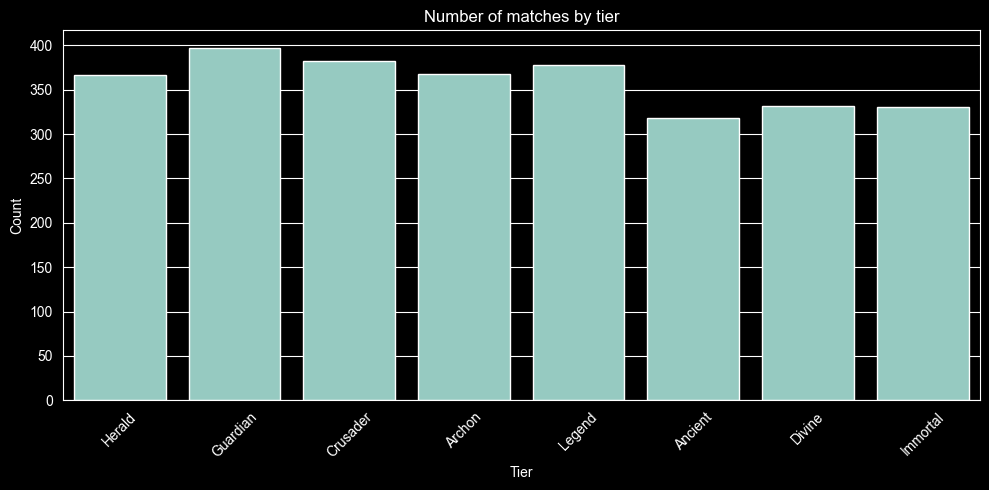

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=tmp, x="tier", order=tier_order)
plt.title("Number of matches by tier")
plt.xlabel("Tier")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Możemy zauważyć, że na każdym poziomie rankingowym rozegrano podobna liczbę meczów,lecz jednak widać lekką przewagę dla poziomów od Gurdian do Legend,co dobrze obrazuje rzeczywistość, gdzie najwięcej graczy posiada właśnie jedna z środkowych rang.

### Selected features boxplot

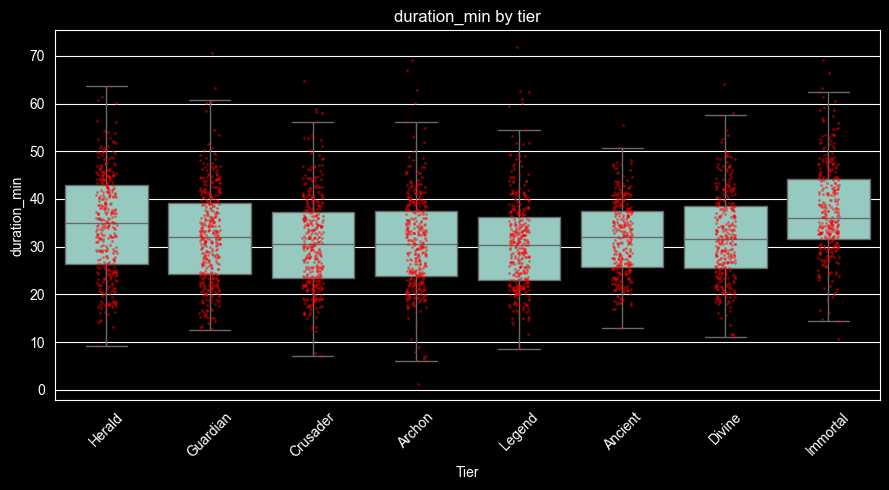

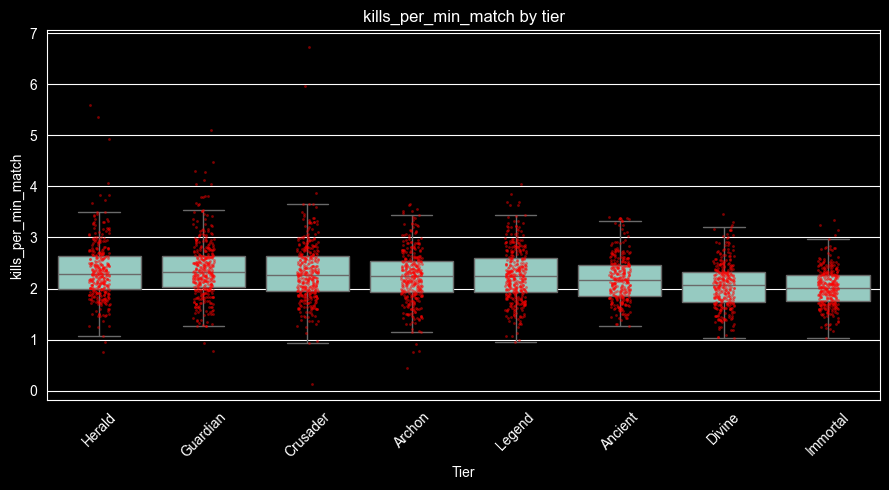

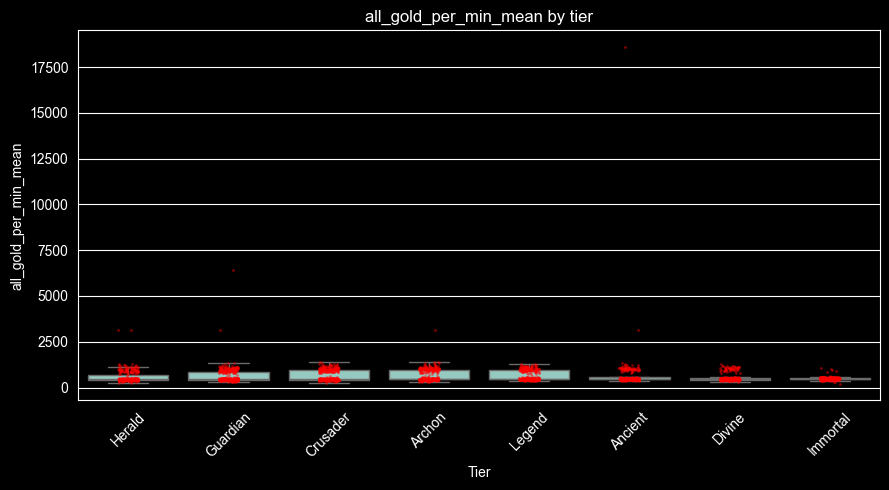

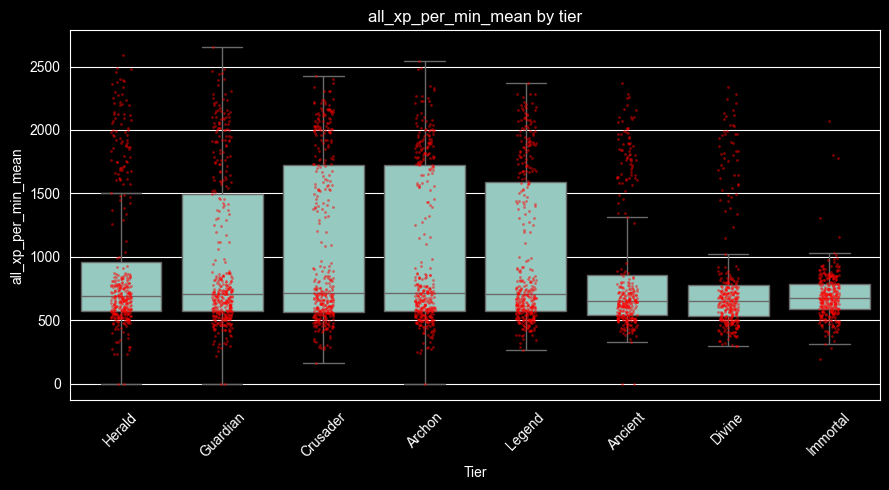

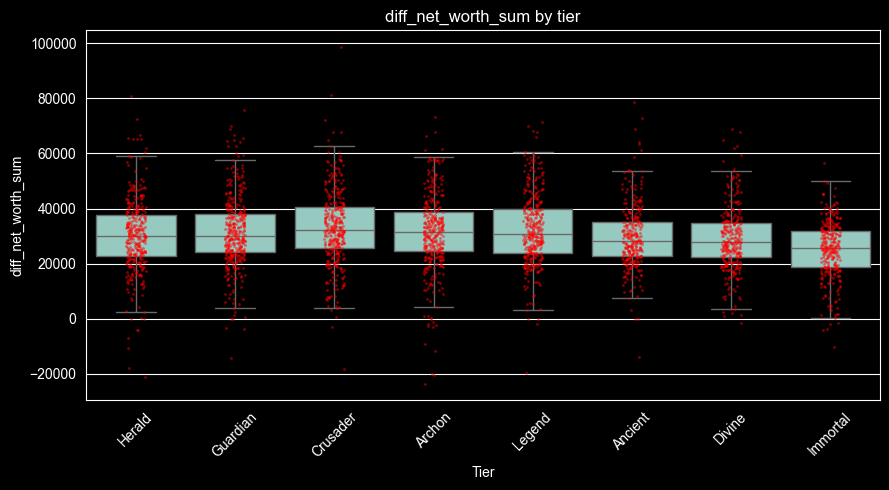

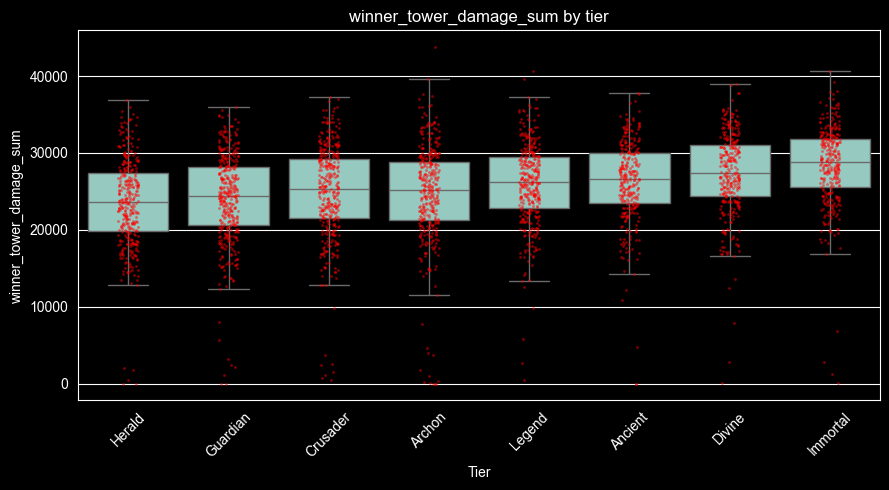

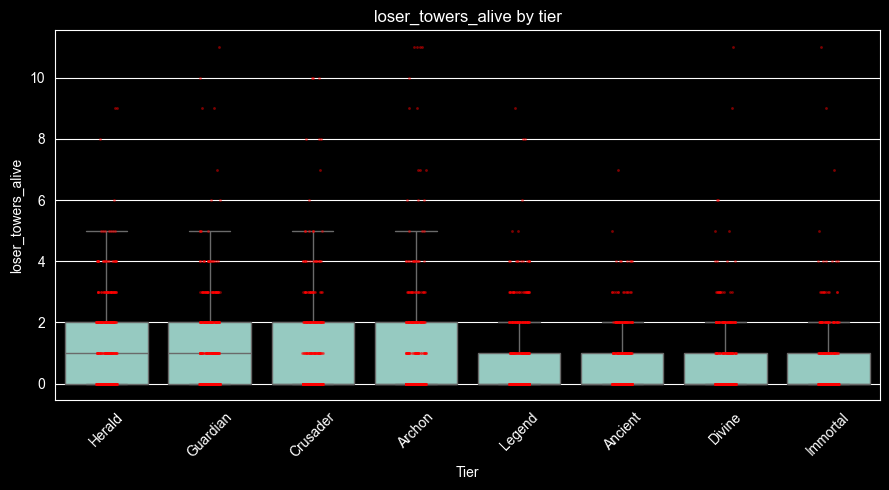

In [14]:
plot_cols = [
    "duration_min",
    "kills_per_min_match",
    "all_gold_per_min_mean",
    "all_xp_per_min_mean",
    "diff_net_worth_sum",
    "winner_tower_damage_sum",
    "loser_towers_alive",
]

for col in plot_cols:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=tmp, x="tier", y=col, order=tier_order, showfliers=False)
    sns.stripplot(
        data=tmp,
        x="tier",
        y=col,
        order=tier_order,
        color="red",
        alpha=0.5,
        size=2,
    )
    plt.title(f"{col} by tier")
    plt.xlabel("Tier")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Boxploty sugerują, że wyższe rangi charakteryzują się bardziej stabilnym i kontrolowanym stylem gry. Widać to m.in. po mniejszym rozrzucie długości meczów oraz spadku liczby zabójstw na minutę wraz ze wzrostem tieru. Jednocześnie rosną statystyki związane z realizacją celów, takie jak obrażenia zadawane wieżom przez zwycięską drużynę. Największe nakładanie się rozkładów dotyczy rang środkowych, zwłaszcza od Crusader do Legend, co może mieć wpływ na poprawne odróżnianie tych rang przez model.

### Mean trend by tier

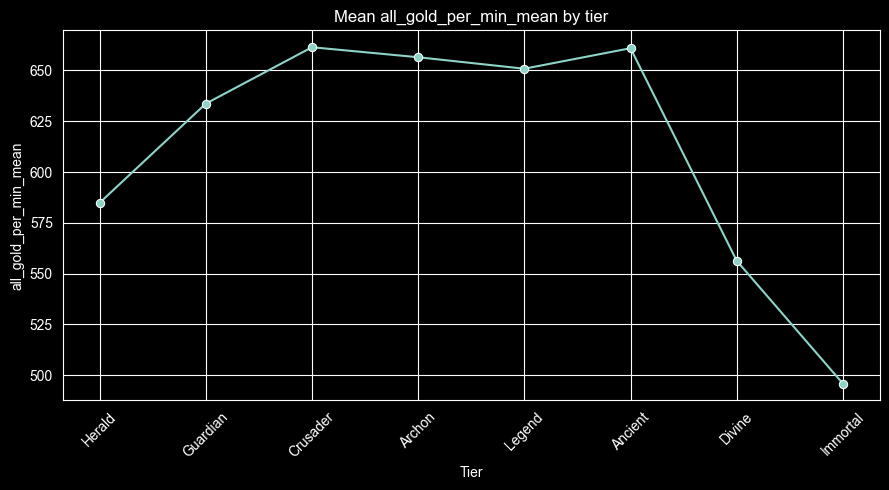

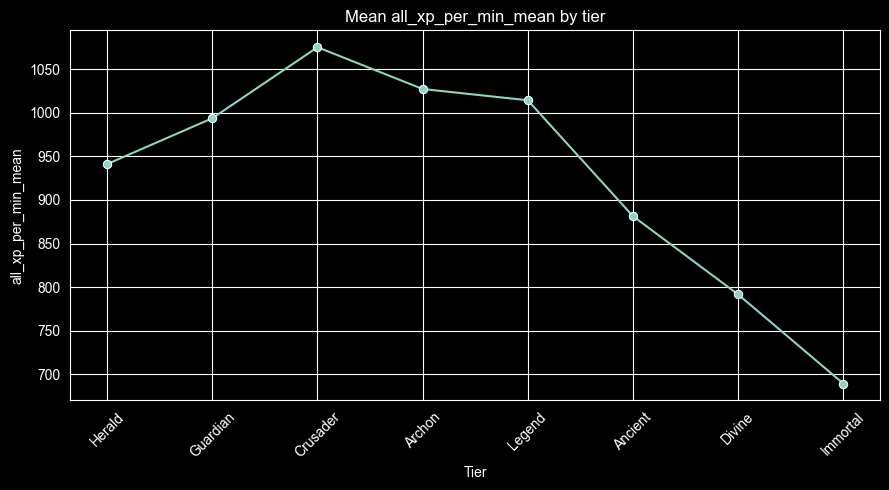

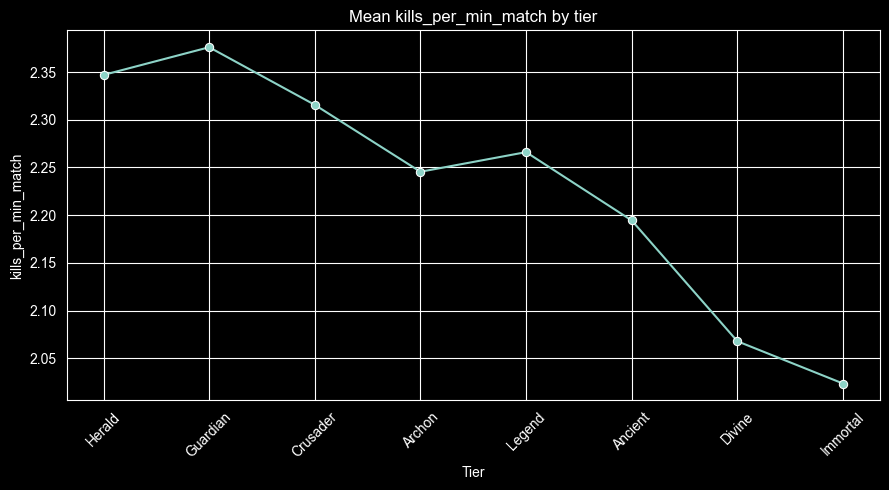

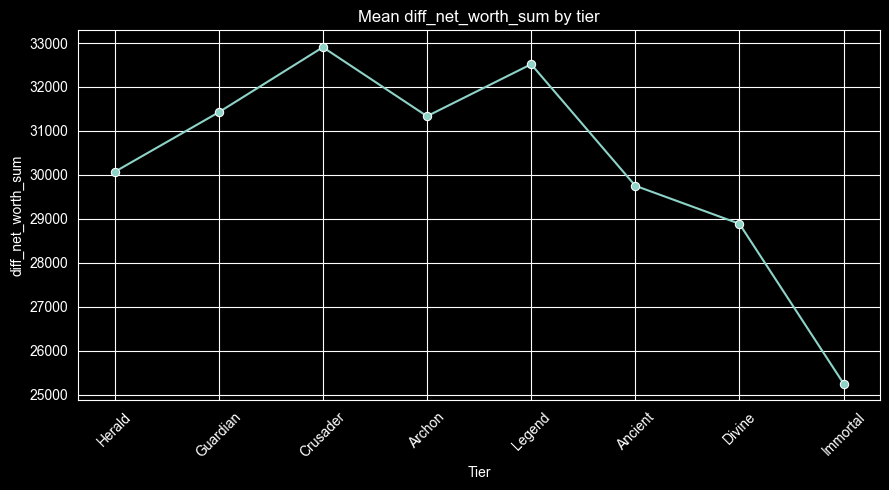

In [15]:
summary_cols = [
    "all_gold_per_min_mean",
    "all_xp_per_min_mean",
    "kills_per_min_match",
    "diff_net_worth_sum",
]

tier_means = tmp.groupby("tier", observed=False)[summary_cols].mean().reset_index()

for col in summary_cols:
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=tier_means, x="tier", y=col, marker="o")
    plt.title(f"Mean {col} by tier")
    plt.xlabel("Tier")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Obserwujac, wykresy średnich wartości, widzimy analogiczne jak w przypadku boxplotow zjawisko wyrównanych wartośći dla średniego levelu rang z dosć wyrażnym spadkiem wartości wraz ze wzrostem rang zawodników.

### Correlation matrix

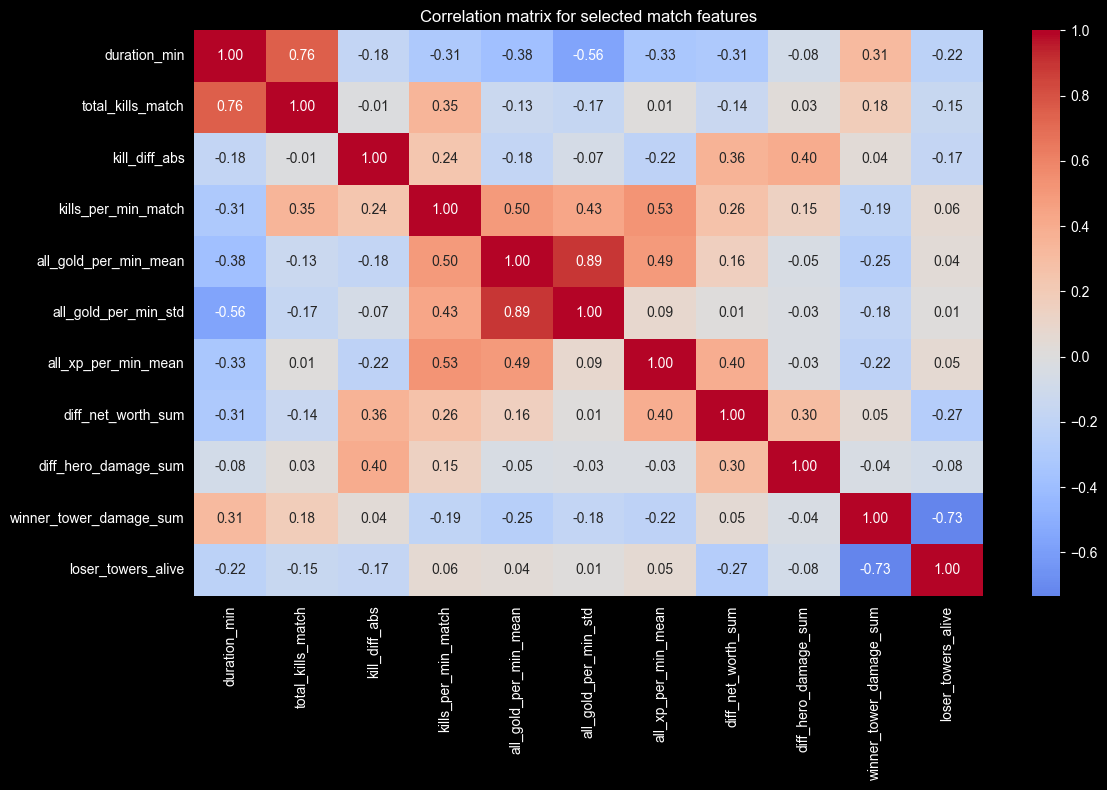

In [16]:
eda_corr_cols = [
    "duration_min",
    "total_kills_match",
    "kill_diff_abs",
    "kills_per_min_match",
    "all_gold_per_min_mean",
    "all_gold_per_min_std",
    "all_xp_per_min_mean",
    "diff_net_worth_sum",
    "diff_hero_damage_sum",
    "winner_tower_damage_sum",
    "loser_towers_alive",
]

plt.figure(figsize=(12, 8))
corr = tmp[eda_corr_cols].corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix for selected match features")
plt.tight_layout()
plt.show()

Z macierzy korealcji można zauważyć silny wziązek łacznej liczby "killi" z dłigością meczu, czy średnia liczba xp a golda na minute.

## 3. ML Pipeline

W tej sekcji porównano kilka wariantów zestawów cech (`economy`, `combat`, `macro`, `compact`, `full`) oraz kilka modeli klasyfikacyjnych.
Dla każdego wariantu przygotowano cechy meczowe, usunięto silnie skorelowane kolumny, a następnie przeprowadzono walidację krzyżową.
Celem było wskazanie najlepszego połączenia: **zestaw cech + model**.


### Walidacja krzyżowa dla różnych zestawów cech i modeli

In [4]:
train_players_df = flatten_matches(train_json)
test_players_df = flatten_matches(test_json)


def get_models():
    logreg_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=3000, random_state=42)),
        ]
    )

    rf_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=400,
                    max_depth=12,
                    min_samples_leaf=3,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    hgb_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                HistGradientBoostingClassifier(
                    max_iter=300, learning_rate=0.05, max_depth=8, random_state=42
                ),
            ),
        ]
    )

    catboost_model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="Accuracy",
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5,
        random_strength=1,
        verbose=False,
        random_state=42,
    )

    return {
        "Logistic Regression": logreg_model,
        "Random Forest": rf_model,
        "HistGradientBoosting": hgb_model,
        "CatBoost": catboost_model,
    }


def prepare_feature_set(
    train_players_df, test_players_df, feature_set, corr_threshold=0.95
):
    train_df = build_match_features(
        players_df=train_players_df, feature_set=feature_set
    )
    test_df = build_match_features(players_df=test_players_df, feature_set=feature_set)

    train_df_reduced, dropped_corr_cols = drop_high_corr_features(
        train_df, threshold=corr_threshold
    )
    test_df_reduced = test_df.drop(columns=dropped_corr_cols, errors="ignore")

    X_train = train_df_reduced.drop(columns=["match_id", "tier"])
    y_train = train_df_reduced["tier"]

    X_test = test_df_reduced.drop(columns=["match_id", "tier"], errors="ignore")
    X_test = X_test.reindex(columns=X_train.columns)

    meta = {
        "feature_set": feature_set,
        "train_shape_before": train_df.shape,
        "test_shape_before": test_df.shape,
        "train_shape_after": train_df_reduced.shape,
        "test_shape_after": test_df_reduced.shape,
        "dropped_corr_cols_count": len(dropped_corr_cols),
        "dropped_corr_cols": dropped_corr_cols,
    }

    return X_train, y_train, X_test, train_df_reduced, test_df_reduced, meta


feature_sets = ["economy", "combat", "macro", "compact", "full"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro", "f1_weighted": "f1_weighted"}

all_cv_results = []
prepared_data = {}

for feature_set in tqdm(feature_sets, desc="Feature sets"):
    X_train, y_train, X_test, train_df_red, test_df_red, meta = prepare_feature_set(
        train_players_df, test_players_df, feature_set=feature_set, corr_threshold=0.95
    )

    prepared_data[feature_set] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "train_df_reduced": train_df_red,
        "test_df_reduced": test_df_red,
        "meta": meta,
    }

    models = get_models()

    for model_name, model in tqdm(
        models.items(), total=len(models), desc=f"Models: {feature_set}", leave=False
    ):
        scores = cross_validate(
            model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
        )

        all_cv_results.append(
            {
                "feature_set": feature_set,
                "model": model_name,
                "n_features": X_train.shape[1],
                "cv_accuracy_mean": scores["test_accuracy"].mean(),
                "cv_accuracy_std": scores["test_accuracy"].std(),
                "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
                "cv_f1_macro_std": scores["test_f1_macro"].std(),
                "cv_f1_weighted_mean": scores["test_f1_weighted"].mean(),
                "cv_f1_weighted_std": scores["test_f1_weighted"].std(),
                "dropped_corr_cols_count": meta["dropped_corr_cols_count"],
            }
        )

cv_results_df = (
    pd.DataFrame(all_cv_results)
    .sort_values(["cv_accuracy_mean", "cv_f1_macro_mean"], ascending=False)
    .reset_index(drop=True)
)

cv_results_df

Models: compact:  25%|██▌       | 1/4 [00:00<00:02,  1.21it/s]/Users/dominik/Desktop/SwSI/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/dominik/Desktop/SwSI/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/dominik/Desktop/SwSI/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib work

,feature_set,model,n_features,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean,cv_f1_weighted_std,dropped_corr_cols_count
0,compact,Logistic Regression,172,0.316155,0.010600,0.311573,0.011481,0.310118,0.011012,98
1,macro,Logistic Regression,66,0.312672,0.012488,0.301785,0.013299,0.299593,0.013875,20
2,full,Logistic Regression,233,0.310577,0.010870,0.306552,0.012846,0.306040,0.012813,127
3,economy,Logistic Regression,156,0.310575,0.013994,0.304753,0.015481,0.303877,0.015269,87
4,economy,CatBoost,156,0.305705,0.008012,0.297044,0.010349,0.295806,0.009956,87
5,full,CatBoost,233,0.305006,0.011664,0.296443,0.017467,0.294762,0.016931,127
6,macro,CatBoost,66,0.301873,0.014147,0.293177,0.015765,0.292075,0.015875,20
7,compact,CatBoost,172,0.298032,0.022781,0.288182,0.026328,0.286621,0.025930,98
8,full,HistGradientBoosting,233,0.296302,0.019000,0.294022,0.020467,0.293132,0.020752,127
9,macro,Random Forest,66,0.289684,0.012006,0.270884,0.018264,0.269848,0.017765,20


Na podstawie wcześniejszych wyników wybrano wariant `compact`, który dawał najlepsze rezultaty przy umiarkowanej liczbie cech.
Dla tego zestawu ponownie przygotowano dane treningowe i testowe, a następnie wykonano strojenie hiperparametrów regresji logistycznej z użyciem `GridSearchCV`.

In [75]:
train_df = build_match_features(players_df=train_players_df, feature_set="compact")
test_df = build_match_features(players_df=test_players_df, feature_set="compact")

train_df_reduced, dropped_corr_cols = drop_high_corr_features(train_df, threshold=0.95)
test_df_reduced = test_df.drop(columns=dropped_corr_cols, errors="ignore")

X_train = train_df_reduced.drop(columns=["match_id", "tier"])
y_train = train_df_reduced["tier"]

X_test = test_df_reduced.drop(columns=["match_id", "tier"], errors="ignore")
X_test = X_test.reindex(columns=X_train.columns)

### Strojenie regresji logistycznej dla wariantu `compact`

In [76]:
logreg_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

param_grid = [
    {
        "clf__solver": ["lbfgs", "newton-cg"],
        "clf__C": np.logspace(-2, 1, 8),
        "clf__class_weight": [None, "balanced"],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=False,
)

grid_search.fit(X_train, y_train)

print("Best score:", grid_search.best_score_)
print("Best params:", grid_search.best_params_)

best_logreg = grid_search.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best score: 0.32067747311013484
Best params: {'clf__C': np.float64(3.727593720314938), 'clf__class_weight': 'balanced', 'clf__solver': 'newton-cg'}


### Generowanie predykcji i zapis pliku submission

In [74]:
test_pred = best_logreg.predict(X_test)

test_pred = pd.Series(test_pred.flatten())

submission = pd.DataFrame({"id": test_df["match_id"], "tier": test_pred})

submission.to_csv("submission_compact.csv", index=False)

print(submission.head())

           id      tier
0  8734589677    Divine
1  8322593710  Guardian
2  8734604126  Crusader
3  8322711315   Ancient
4  8734606107    Archon
